In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
seed = 42
prefix_path = "../"

In [3]:
data = pd.read_csv(prefix_path + "data/raw/Student_Performance.csv", index_col=0)

In [4]:
data.head()

,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,,,,,
7,99,Yes,9,1,91.0
4,82,No,4,2,65.0
8,51,Yes,7,2,45.0
5,52,Yes,5,2,36.0
7,75,No,8,5,66.0


In [5]:
X, y = np.array(data.drop(columns=["Performance Index"])), np.array(data["Performance Index"])

In [6]:
X.shape, y.shape

((10000, 4), (10000,))

In [7]:
X, y

(array([[99, 'Yes', 9, 1],
        [82, 'No', 4, 2],
        [51, 'Yes', 7, 2],
        ...,
        [83, 'Yes', 8, 5],
        [97, 'Yes', 7, 0],
        [74, 'No', 8, 1]], shape=(10000, 4), dtype=object),
 array([91., 65., 45., ..., 74., 95., 64.], shape=(10000,)))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=seed)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 4), (2000, 4), (8000,), (2000,))

In [10]:
MAX_ITERATIONS = 2e5
TOLERANCE = 1e-2

In [11]:
X_train

array([[49, 'No', 7, 5],
       [48, 'Yes', 7, 6],
       [81, 'No', 7, 2],
       ...,
       [48, 'No', 7, 6],
       [47, 'No', 9, 0],
       [46, 'No', 6, 6]], shape=(8000, 4), dtype=object)

In [12]:
def is_binary(col):
        unique_vals = pd.Series(col).dropna().unique()
        if len(unique_vals) == 2:
            lowered = [str(v).strip().lower() for v in unique_vals]
            binary_sets = [{'true', 'false'}, {'false', 'true'}, {'yes', 'no'}, {'no', 'yes'}, {'0', '1'}, {'1', '0'}]
            if set(lowered) in binary_sets:
                return True
            if pd.Series(unique_vals).dtype == bool:
                return True
            if set(unique_vals) <= {0, 1}:
                return True
        return False

def convert_binary_column(col: pd.Series) -> pd.Series:
    mapping = {'true': 1, 'false': 0, 'yes': 1, 'no': 0, True: 1, False: 0, '1': 1, '0': 0}
    return col.astype(str).str.lower().map(mapping).astype(float)

In [13]:
def normalization(data) -> np.array:
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)
    
    # Try converting numeric-like columns safely
    for col in data.columns:
        try:
            data[col] = pd.to_numeric(data[col])
        except (ValueError, TypeError):
            pass  # leave as is if not convertible
    
    # Identify the numerical and categorical columns
    num_cols = data.select_dtypes(include=[np.number]).columns
    cat_cols = data.select_dtypes(exclude=[np.number]).columns

    # Create as copy of dataframe
    data_norm = data.copy()

    # Normalize only the numeric columns
    for col in num_cols:
        min_val = data[col].min()
        max_val = data[col].max()
        diff = max_val - min_val
        if diff != 0:
            data_norm[col] = (data[col] - min_val) / diff
    
    for col in cat_cols:
        if is_binary(data[col]):
            data_norm[col] = convert_binary_column(data[col])

    # Returns the same type expected, a numpy array
    return data_norm.to_numpy() if isinstance(data, pd.DataFrame) else data_norm

In [14]:
X_train_norm = normalization(X_train)
#y_train_norm = normalization(y_train)

In [17]:
def standardization(data) -> np.array:
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)
    
    # Safely convert numeric-like columns
    for col in data.columns:
        try:
            data[col] = pd.to_numeric(data[col])
        except (ValueError, TypeError):
            pass  # keep categorical columns unchanged

    # Identify numeric and categorical columns
    num_cols = data.select_dtypes(include=[np.number]).columns
    cat_cols = data.select_dtypes(exclude=[np.number]).columns

    data_std = data.copy()

    # Standardize numeric columns
    for col in num_cols:
        mean_val = data[col].mean()
        std_val = data[col].std()
        if std_val != 0:
            data_std[col] = (data[col] - mean_val) / std_val

    # Convert binary categorical columns
    for col in cat_cols:
        if is_binary(data[col]):
            data_std[col] = convert_binary_column(data[col])

    # Attempt to convert everything numeric-like back to numeric
    for col in data_std.columns:
        try:
            data_std[col] = pd.to_numeric(data_std[col])
        except (ValueError, TypeError):
            pass

    return data_std.to_numpy()


In [18]:
X_train_z = standardization(X_train)
y_train_z = standardization(y_train)

In [19]:
X_train

array([[49, 'No', 7, 5],
       [48, 'Yes', 7, 6],
       [81, 'No', 7, 2],
       ...,
       [48, 'No', 7, 6],
       [47, 'No', 9, 0],
       [46, 'No', 6, 6]], shape=(8000, 4), dtype=object)

In [20]:
X_train_z

array([[-1.1837704 ,  0.        ,  0.26987161,  0.13403274],
       [-1.24142811,  1.        ,  0.26987161,  0.48353142],
       [ 0.66127625,  0.        ,  0.26987161, -0.91446328],
       ...,
       [-1.24142811,  0.        ,  0.26987161,  0.48353142],
       [-1.29908582,  0.        ,  1.44738613, -1.61346063],
       [-1.35674353,  0.        , -0.31888565,  0.48353142]],
      shape=(8000, 4))

In [21]:
def f(X: np.array, w: float, b: float) -> float:
    return w * X + b

In [29]:
def loss_function(X: np.array, y: np.array, w: float, b: float, metric: str) -> float:
    # Mean Squared Error (MSE)
    if metric.strip().lower() == "mse":
        return (1/(2 * X.shape[0])) * np.sum( (f(X, w, b) - y)**2 )

In [30]:
def update_coefficients(X: np.array, y: np.array, w: float, b: float, lr: float, metric: str, method: str) -> float:
    # Gradient Descent (GD)
    if method.strip().lower() == "gd":
        def d_loss_function(X: np.array, y: np.array, w: float, b: float, metric: str) -> float:
            # Derivatives of Mean Squared Error
            if metric.strip().lower() == "mse":
                dw = (1/X.shape[0]) * np.sum( (f(X, w, b) - y) * X )
                db = (1/X.shape[0]) * np.sum( f(X, w, b) - y )
                return dw, db
    
        dw, db = d_loss_function(X, y, w, b, metric)
        aux_w = w - lr * dw
        aux_b = b - lr * db
        return aux_w, aux_b

In [31]:
def gradient_descent(X: np.array, y: np.array, lr: float, metric: str):
    # Defining returnning structure
    hist_cost = list()
    hist_w_b = list()

    i = 1 # Iterations counter
    # Generating initial values for w and b
    w, b = 6, 7
    # Initial cost
    cost = loss_function(X, y, w, b, metric)
    hist_cost.append(cost)
    while (cost > TOLERANCE) and i < MAX_ITERATIONS:
        w, b = update_coefficients(X, y, w, b, lr, metric, method="gd")    # Update the coefficients of f
        cost = loss_function(X, y, w, b, metric)             # The total cost related to new coefficients
        # Saving the history
        hist_w_b.append((w, b))
        hist_cost.append(cost)
        i += 1
    
    return hist_w_b, hist_cost, i

In [32]:
def linear_regression(X: np.array, y: np.array, lr: float, metric: str, method: str) -> float:
    if method.strip().lower() == "gd":
        return gradient_descent(X, y, lr, metric)

In [33]:
X_train_norm = normalization(X_train)
y_train_norm = normalization(y_train)

X_train_z = standardization(X_train)
y_train_z = standardization(y_train)

In [34]:
inputs = {"X": X_train_norm, "y": y_train_norm, "lr": 0.1, "metric": "mse", "method": "gd"}
list_w_b, list_cost, total_iterations = linear_regression(**inputs)

In [35]:
len(list_cost), total_iterations

(200000, 200000)

In [36]:
def learning_curve(cost: list) -> None:
    x_len = len(cost)
    plt.plot(np.arange(x_len), cost, label="Loss")
    plt.xticks(ticks=np.arange(0, x_len+1, (MAX_ITERATIONS / 1e1)), rotation=45)
    plt.legend()

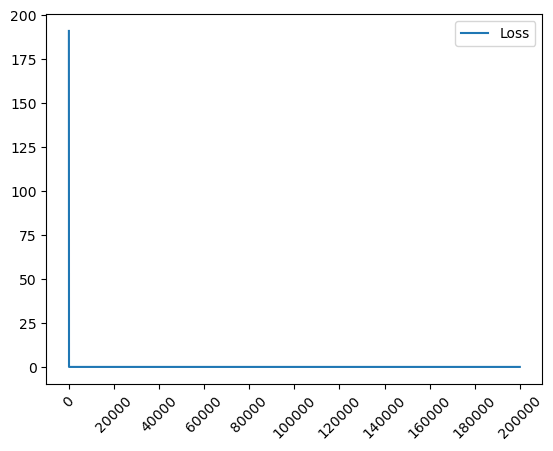

In [37]:
learning_curve(list_cost)

In [ ]:
min(list_cost)

In [ ]:
X_test_norm = normalization(X_test)
y_test_norm = normalization(y_test)

X_test_z = standardization(X_test)
y_test_z = standardization(y_test)

In [ ]:
inputs = {"X": X_test_norm, "y": y_test_norm, "lr": 0.1, "metric": "mse", "method": "gd"}
list_w_b, list_cost, total_iterations = linear_regression(**inputs)

In [ ]:
learning_curve(list_cost)

In [ ]:
list_cost[-1]